Saving CS6795 DB.txt to CS6795 DB (4).txt
Number of original sequences: 68
Original labels: ['CaoSC', 'SC_MT29', 'SC_486', 'SC_583', 'BamL', 'Bam_388', 'Bam_722', 'Bam_076', 'BpumL', 'Bpum_460']
Family labels: ['Age', 'Aln', 'Anc', 'Bam', 'Bpum', 'CYP', 'Div', 'Lah', 'Leg', 'Lxm', 'Olv', 'PTT', 'Pho', 'SC', 'Stsp', 'bmb', 'dpOp']
Number of sequence fragments: 263

Class counts:
Age 23
Aln 16
Anc 12
Bam 10
Bpum 9
CYP 11
Div 11
Lah 24
Leg 17
Lxm 10
Olv 20
PTT 12
Pho 16
SC 15
Stsp 17
bmb 11
dpOp 29

Training samples: 184
Test samples: 79

Selected labels in narrow condition:
[np.str_('PTT'), np.str_('Pho'), np.str_('Anc'), np.str_('Leg'), np.str_('Stsp'), np.str_('dpOp'), np.str_('bmb'), np.str_('Age')]

Diverse Accuracy: 0.8608
Narrow Accuracy: 0.8333

Diverse classification report:
              precision    recall  f1-score   support

         Age       0.88      1.00      0.93         7
         Aln       1.00      1.00      1.00         5
         Anc       0.60      0.75      0.67  

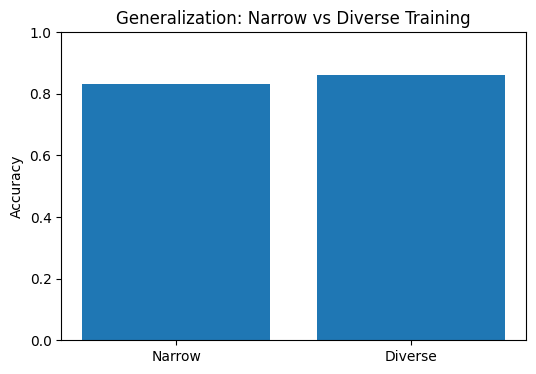

In [4]:
from google.colab import files
uploaded = files.upload()
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt
import re

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# -------------------------
# 1. Load FASTA-like file
# -------------------------
def load_fasta(file_path):
    sequences = []
    labels = []

    with open(file_path, "r") as f:
        name = None
        seq = ""

        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if name is not None:
                    sequences.append(seq)
                    labels.append(name)

                name = line[1:].split()[0]
                seq = ""
            else:
                seq += line

        if name is not None:
            sequences.append(seq)
            labels.append(name)

    return sequences, labels


# -------------------------
# 2. Convert sequence names to family labels
# -------------------------
def to_family_label(name):
    # If name has underscore, use prefix before underscore
    if "_" in name:
        return name.split("_")[0]

    # Manual cleanup for parent names
    manual_map = {
        "CaoSC": "SC",
        "BamL": "Bam",
        "BpumL": "Bpum",
        "PhomM": "Pho",
        "CYPM": "CYP",
        "LegD": "Leg",
        "DivMT": "Div",
        "LxmM": "Lxm",
        "OlvSA": "Olv",
        "LahSB": "Lah",
        "dbOphMA": "dpOp",
        "AgeMT": "Age",
        "StspM": "Stsp",
        "bmbA": "bmb",
        "AncMT": "Anc",
        "PTTMT": "PTT",
        "AlnMT": "Aln",
    }

    return manual_map.get(name, name)


# -------------------------
# 3. Split each sequence into fragments
# -------------------------
def split_sequence_into_fragments(sequence, fragment_length=120, step=60):
    fragments = []

    if len(sequence) < fragment_length:
        return [sequence]

    for i in range(0, len(sequence) - fragment_length + 1, step):
        frag = sequence[i:i+fragment_length]
        fragments.append(frag)

    return fragments


def expand_dataset_with_fragments(sequences, labels, fragment_length=120, step=60):
    new_sequences = []
    new_labels = []

    for seq, label in zip(sequences, labels):
        fragments = split_sequence_into_fragments(seq, fragment_length=fragment_length, step=step)
        new_sequences.extend(fragments)
        new_labels.extend([label] * len(fragments))

    return new_sequences, new_labels


# -------------------------
# 4. k-mer feature extraction
# -------------------------
def build_kmer_vocab(sequences, k=2):
    vocab = set()
    for seq in sequences:
        for i in range(len(seq) - k + 1):
            vocab.add(seq[i:i+k])
    return sorted(vocab)


def kmer_features(sequences, vocab, k=2):
    features = []

    for seq in sequences:
        counts = Counter(seq[i:i+k] for i in range(len(seq) - k + 1))
        total = sum(counts.values())

        if total == 0:
            vec = [0] * len(vocab)
        else:
            vec = [counts.get(kmer, 0) / total for kmer in vocab]

        features.append(vec)

    return np.array(features)


# -------------------------
# 5. Main experiment
# -------------------------
file_path = "CS6795 DB (3).txt"   # change if needed

sequences, raw_labels = load_fasta(file_path)
family_labels = [to_family_label(x) for x in raw_labels]

print("Number of original sequences:", len(sequences))
print("Original labels:", raw_labels[:10])
print("Family labels:", sorted(set(family_labels)))

fragment_length = 120
step = 60

frag_sequences, frag_labels = expand_dataset_with_fragments(
    sequences, family_labels, fragment_length=fragment_length, step=step
)

print("Number of sequence fragments:", len(frag_sequences))

k = 2
vocab = build_kmer_vocab(frag_sequences, k=k)
X = kmer_features(frag_sequences, vocab=vocab, k=k)
y = np.array(frag_labels)

# check class counts
unique, counts = np.unique(y, return_counts=True)
print("\nClass counts:")
for u, c in zip(unique, counts):
    print(u, c)

# split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nTraining samples:", len(X_train_full))
print("Test samples:", len(X_test))

# -------------------------
# Condition B: Diverse
# -------------------------
model_diverse = RandomForestClassifier(n_estimators=100, random_state=42)
model_diverse.fit(X_train_full, y_train_full)
y_pred_diverse = model_diverse.predict(X_test)
acc_diverse = accuracy_score(y_test, y_pred_diverse)

# -------------------------
# Condition A: Narrow
# -------------------------
unique_labels = sorted(list(set(y_train_full)))
n_select = max(3, len(unique_labels) // 2)
selected_labels = random.sample(unique_labels, n_select)

mask_train_narrow = np.isin(y_train_full, selected_labels)
X_train_narrow = X_train_full[mask_train_narrow]
y_train_narrow = y_train_full[mask_train_narrow]

mask_test_narrow = np.isin(y_test, selected_labels)
X_test_narrow = X_test[mask_test_narrow]
y_test_narrow = y_test[mask_test_narrow]

model_narrow = RandomForestClassifier(n_estimators=100, random_state=42)
model_narrow.fit(X_train_narrow, y_train_narrow)
y_pred_narrow = model_narrow.predict(X_test_narrow)
acc_narrow = accuracy_score(y_test_narrow, y_pred_narrow)

print("\nSelected labels in narrow condition:")
print(selected_labels)

print("\nDiverse Accuracy:", round(acc_diverse, 4))
print("Narrow Accuracy:", round(acc_narrow, 4))

print("\nDiverse classification report:")
print(classification_report(y_test, y_pred_diverse, zero_division=0))

print("\nNarrow classification report:")
print(classification_report(y_test_narrow, y_pred_narrow, zero_division=0))

plt.figure(figsize=(6,4))
plt.bar(["Narrow", "Diverse"], [acc_narrow, acc_diverse])
plt.ylabel("Accuracy")
plt.title("Generalization: Narrow vs Diverse Training")
plt.ylim(0, 1)
plt.show()
